In [1]:
import sys
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from mnist_classifier.data import MNISTDataModule
from nn_utils import get_hidden_states, load_models
from nn_plotting import plot_perturved_accuracy, plot_logit_effects
from local_corex import LinearCorex, partition_data
from local_corex._transformers import CorExWrapper, PCAWrapper
from local_corex.utils.plotting import (
    hidden_state_plot,
    multi_rep_plot,
)

Install CUDA and cudamat (for python) to enable GPU speedups.


In [2]:
# base_path = "./mnist_classifier/model_output/do_classifier/rep_1"
base_path = "./mnist_classifier/model_output/base_classifier/rep_1"

from mnist_classifier.model_output.do_classifier.rep_1.autoencoder_config import conf as ae_conf
# from scripts.mnist_classifier.model_output.base_classifier.rep_1.autoencoder_config import conf as ae_conf
from mnist_classifier.model_output.do_classifier.rep_1.config import conf as clf_conf
# from scripts.mnist_classifier.model_output.base_classifier.rep_1.config import conf as clf_conf

ae_conf = ae_conf['autoencoder']
# ae_ckpt = base_path + '/mnist_ae_epoch=084-val_loss=0.5200.ckpt'
ae_ckpt = base_path + '/mnist_ae_epoch=091-val_loss=0.5937.ckpt'
clf_conf = clf_conf['classifier']
# clf_ckpt = base_path + '/mnist_clf_epoch=042-val_loss=0.0024.ckpt'
clf_ckpt = base_path + '/mnist_clf_epoch=068-val_loss=0.0006.ckpt'

do_ae, do_clf = load_models(ae_ckpt, clf_ckpt, ae_conf, clf_conf)

data_module = MNISTDataModule(clf_conf, "./mnist_classifier/")
data_module.setup('predict')

model_data = get_hidden_states(do_clf, data_module, device=do_clf.device, num_layers=len(clf_conf['hidden_layers']))

inputs=model_data[4]
labels=model_data[5]

do_state_df = pd.DataFrame({
    'input': list(inputs),
    'h1': list(model_data[1]),
    'h2': list(model_data[2]),
    'h3': list(model_data[3]),
    'output': list(model_data[0])
})

loading clusters
Group number: 0 Counter({1: 409, 4: 9, 7: 8, 9: 6, 6: 1})
Group number: 1 Counter({3: 781, 8: 12, 5: 11, 2: 2, 9: 1})
Group number: 2 Counter({9: 408, 4: 54, 7: 13, 8: 7, 2: 1, 5: 1, 1: 1, 3: 1})
Group number: 3 Counter({0: 540, 2: 2, 6: 2, 9: 1})
Group number: 4 Counter({1: 332, 7: 12, 2: 5, 6: 2, 4: 2, 8: 1, 9: 1, 0: 1})
Group number: 5 Counter({6: 402, 5: 7, 0: 5, 4: 3, 2: 3, 8: 2})
Group number: 6 Counter({2: 527, 7: 7, 1: 4, 8: 2, 3: 2, 9: 1})
Group number: 7 Counter({2: 437, 9: 2})
Group number: 8 Counter({6: 534, 4: 2, 9: 1, 0: 1})
Group number: 9 Counter({8: 354, 9: 12, 2: 8, 3: 7, 5: 2, 4: 1})
Group number: 10 Counter({9: 401, 4: 286, 7: 16, 8: 7, 5: 3, 3: 1})
Group number: 11 Counter({4: 348, 9: 1, 8: 1, 7: 1})
Group number: 12 Counter({7: 491, 3: 6, 2: 3, 9: 3, 8: 3, 5: 1})
Group number: 13 Counter({4: 268, 9: 129, 7: 4, 6: 1})
Group number: 14 Counter({1: 380, 7: 6, 4: 4, 8: 1, 5: 1, 2: 1})
Group number: 15 Counter({8: 493, 3: 146, 5: 25, 9: 14, 2: 13, 1: 9

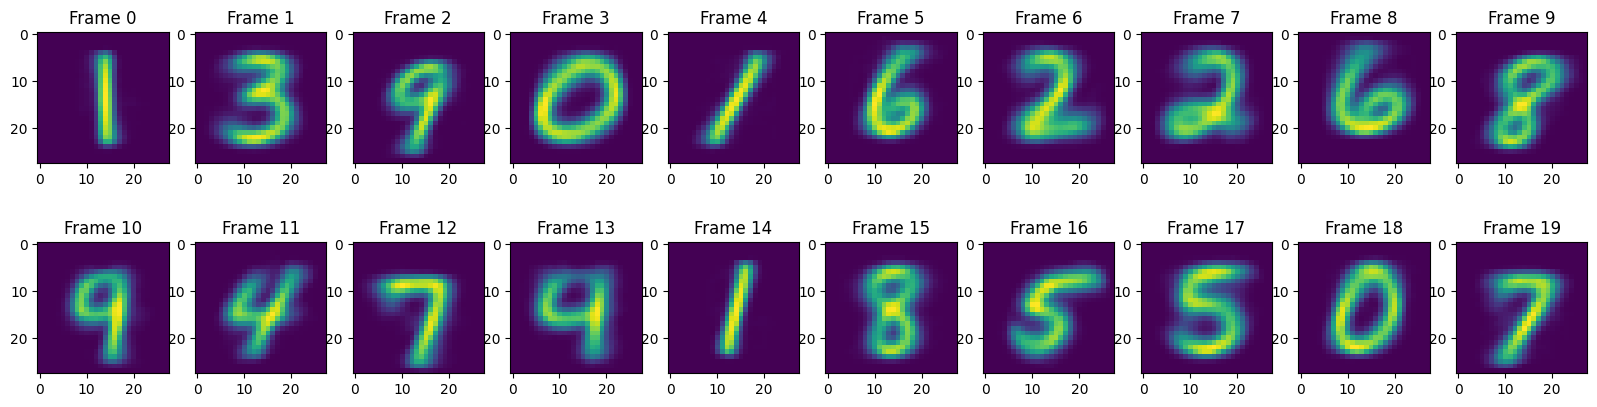

In [3]:
import pickle
from_scratch = False
num_clusters=20

if from_scratch:
    print('computing clusters from scratch')
    indexes, pred = partition_data(inputs, n_partitions=num_clusters, phate_dim=10, n_jobs=-2, seed=42, return_pred=True)
    print('saving clusters')
    with open('mnist_20_indexes.pkl', 'wb') as f:
        pickle.dump(indexes, f)
else:
    print("loading clusters")
    with open('mnist_20_indexes.pkl', 'rb') as f:
        indexes = pickle.load(f)

for i in range(0, num_clusters):
    print("Group number:", i, Counter(labels[indexes[i]]))

fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(np.mean(inputs[indexes[i]], axis = 0).reshape(28,28))
    ax.set_title('Frame ' + str(i))

[ 4.42663682e+01  2.79586735e+01  9.50583451e+00  8.05210159e+00
  6.39316581e+00  5.91735431e+00  4.86148419e+00  3.03470935e+00
  2.25691706e+00  1.07872734e+00  9.67003701e-01  7.09587339e-01
  4.60877184e-01 -2.06894754e-02 -3.04511933e-01 -4.04111730e-01
 -4.31168852e-01 -5.00970179e-01 -5.51474894e-01 -5.80235820e-01
 -6.26035973e-01 -6.36972591e-01 -6.52275154e-01 -6.94526027e-01
 -7.21790966e-01 -7.37036656e-01 -7.37346484e-01 -7.92602512e-01
 -8.06384417e-01 -8.28270153e-01]


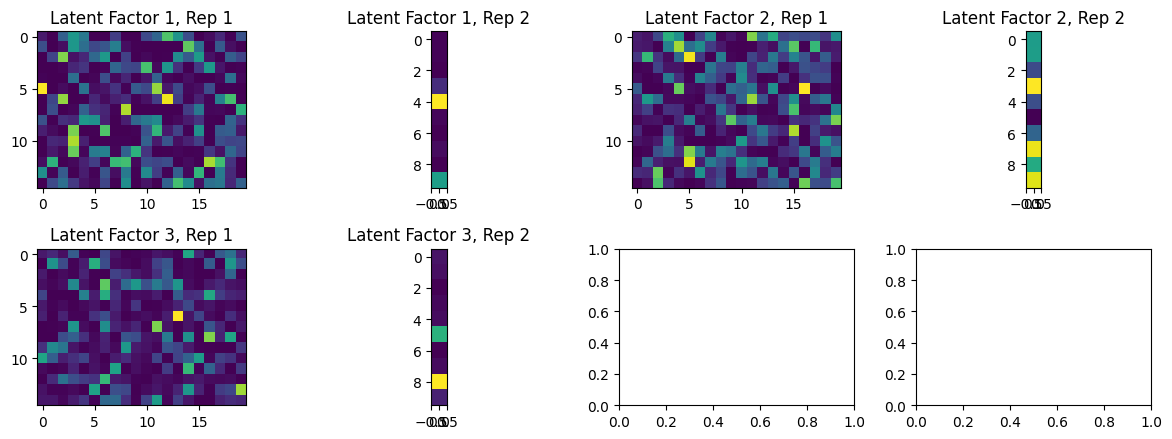

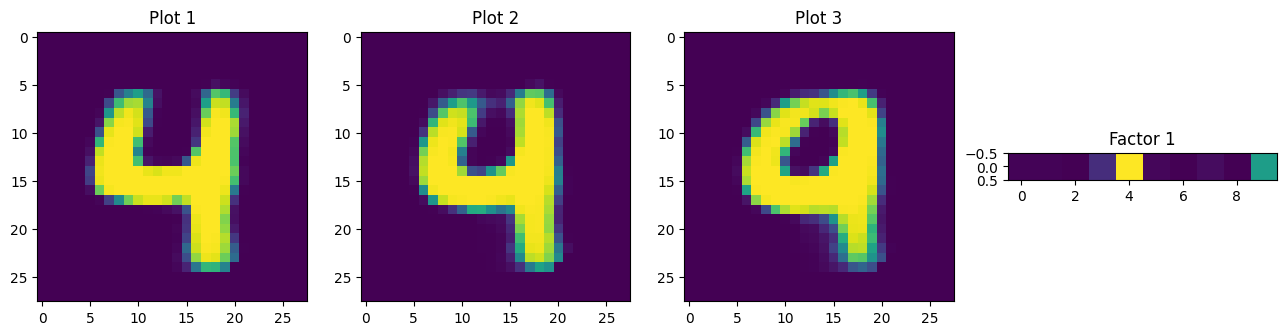

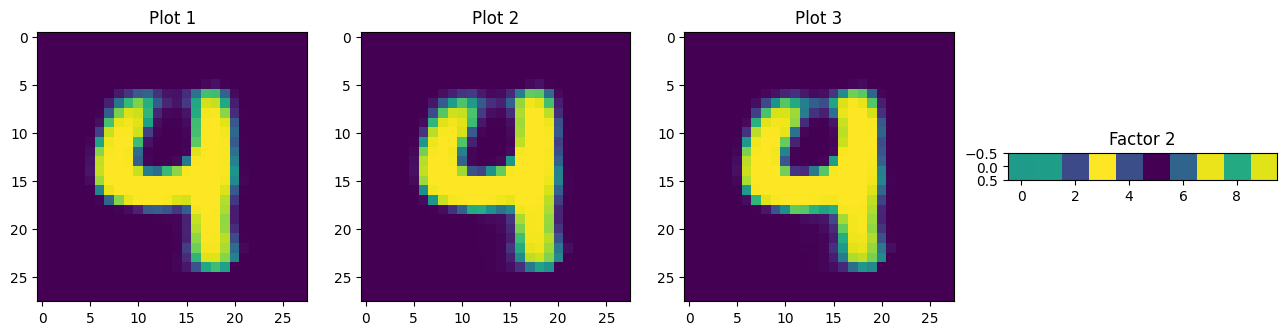

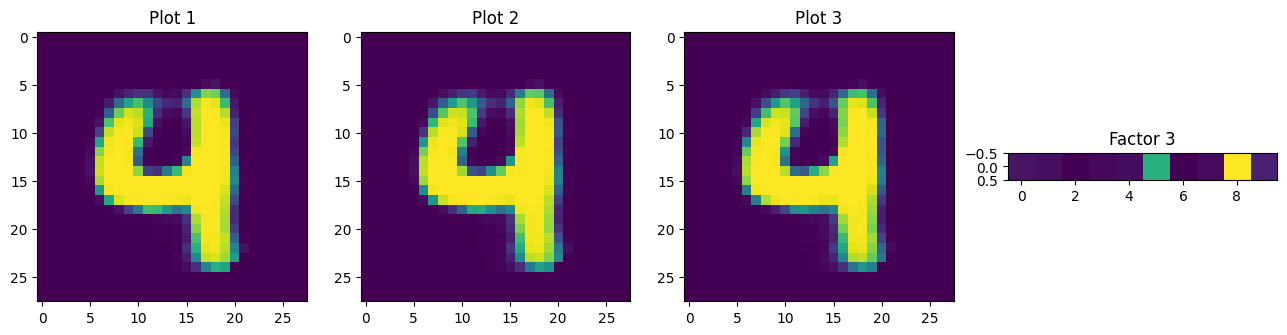

In [4]:
from local_corex import LinearCorex

partition=13
x = np.concatenate([model_data[3][indexes[partition]], model_data[0][indexes[partition]]], axis=1)

h3_to_out_13 = LinearCorex(n_hidden=30, seed=42, gaussianize='outliers', discourage_overlap=False)
Y1_0 = h3_to_out_13.fit_transform(x)
print(h3_to_out_13.tcs)
multi_rep_plot(h3_to_out_13, 3, dims=[(15,20),(10,1)], num_per_row=2)
hidden_state_plot(x, h3_to_out_13, do_ae, factors=list(range(3)), latent_dim=ae_conf['decoder_layers'][0], encoder_layer=3, scaler=1)

[17.976347  16.97525   12.557732  10.070277   8.603028   8.107388
  7.540805   7.227387   7.135292   6.436256   6.189711   6.0126414
  5.625907   5.5155764  3.894606   3.7816517  3.7538486  3.6246824
  3.4654903  3.2708664  3.2651486  3.0735438  2.9243455  2.828035
  2.527721   2.522012   1.9801146  1.9696624  1.9411864  1.37526  ]


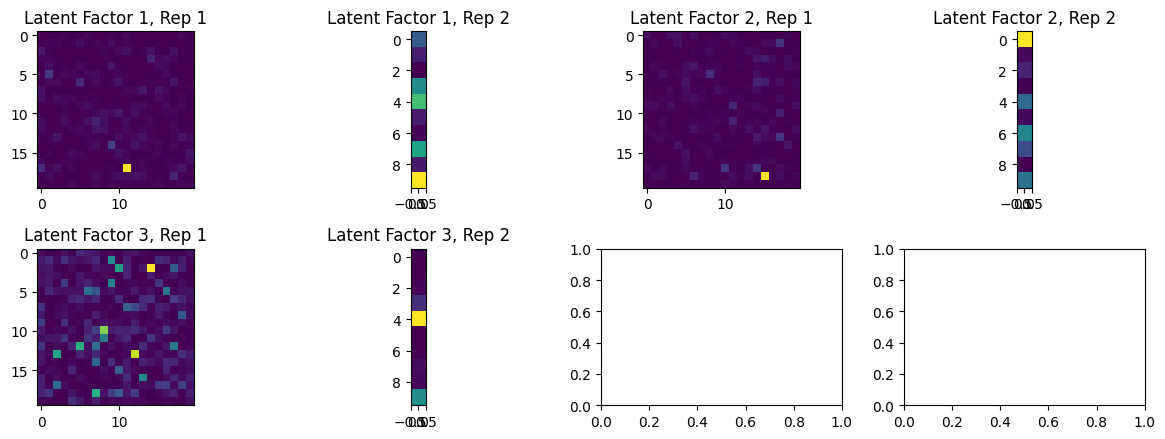

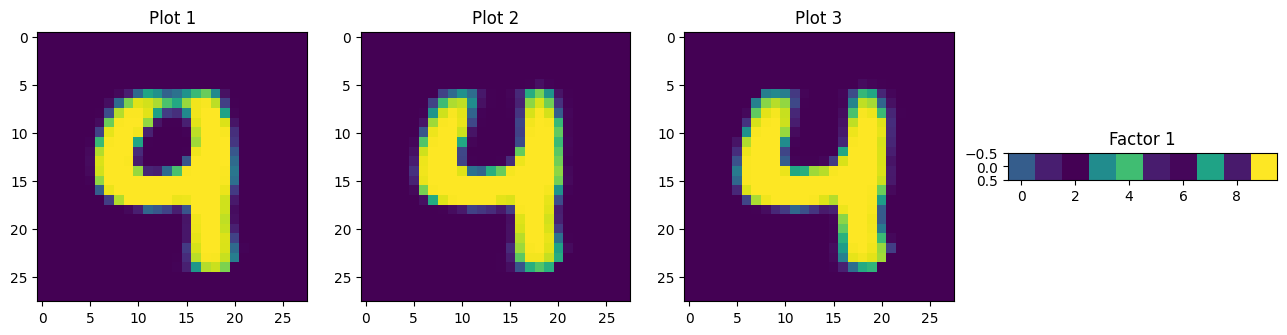

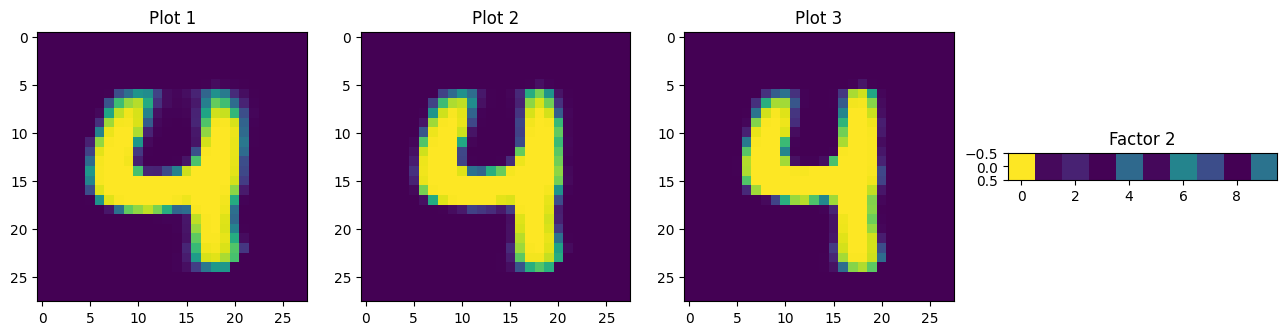

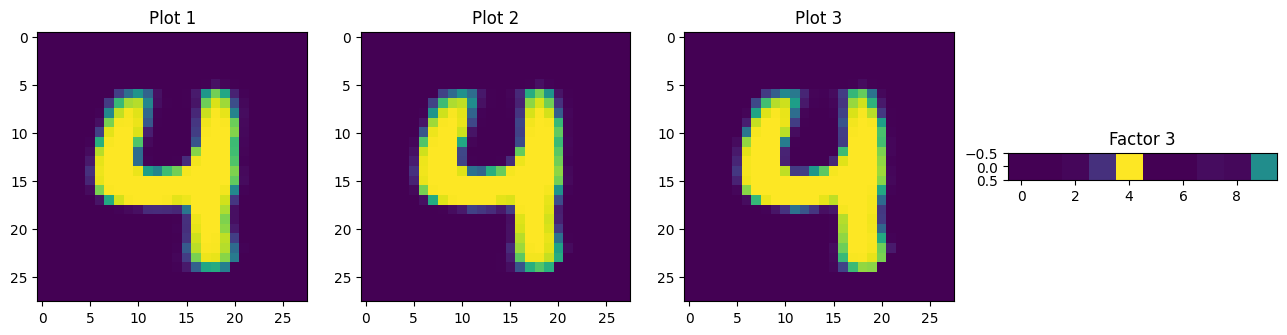

In [5]:
h2_to_out_13 = LinearCorex(n_hidden=30, seed=42, gaussianize='outliers')
x = np.concatenate([model_data[2][indexes[partition]], model_data[0][indexes[partition]]], axis=1)
Y1_0 = h2_to_out_13.fit_transform(x)

print(h2_to_out_13.tcs)
multi_rep_plot(h2_to_out_13, 3, dims=[(20,20),(10,1)], num_per_row=2)
hidden_state_plot(x, h2_to_out_13, do_ae, factors=list(range(3)), latent_dim=400, encoder_layer=2, scaler=1)

[15.922288  11.209748  10.275988   9.77252    9.673454   9.162804
  8.980474   8.687331   6.8532257  6.0139303  5.996085   5.815951
  5.790866   5.0233397  4.762395   4.423339   4.0463743  3.8204556
  3.7827425  3.6276555  3.3330166  3.1070626  3.0994835  3.06507
  2.7713752  2.7420328  2.567513   2.2914815  2.04498    2.0384986]


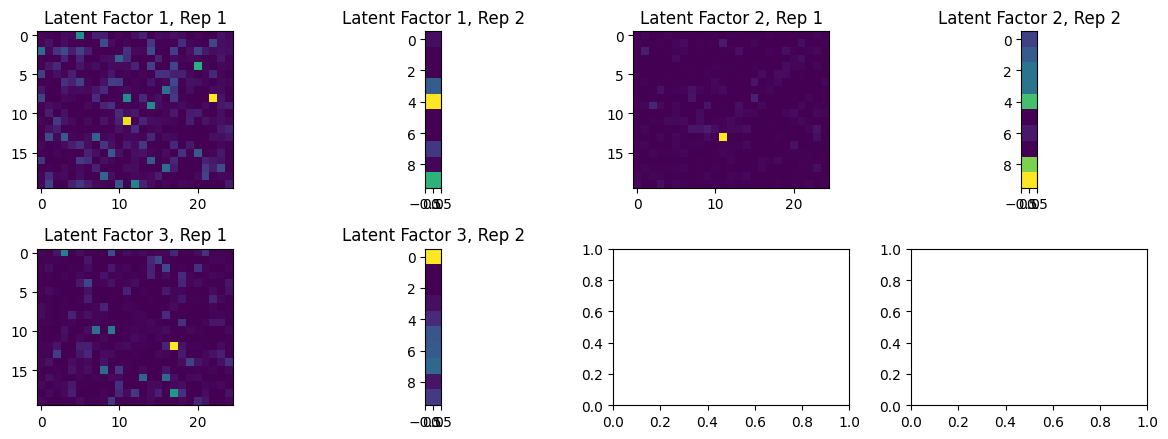

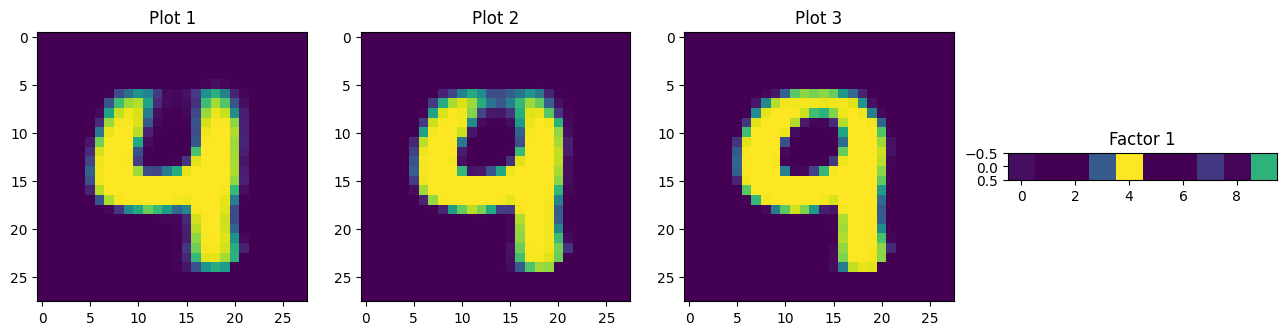

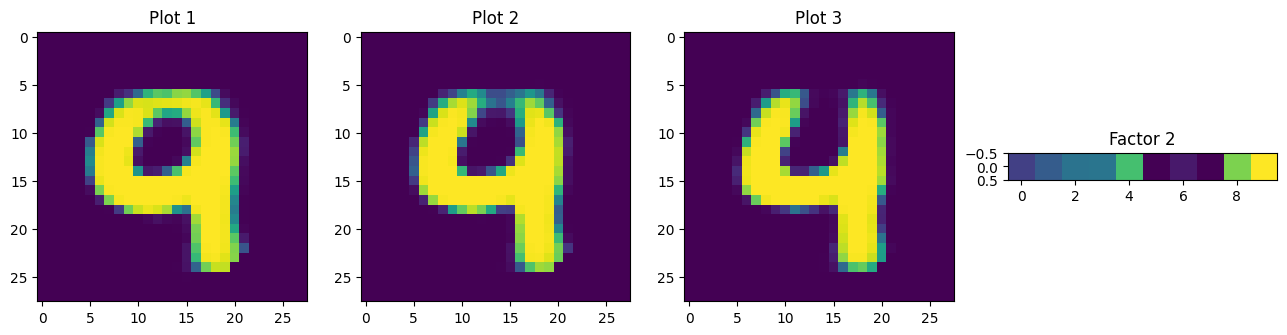

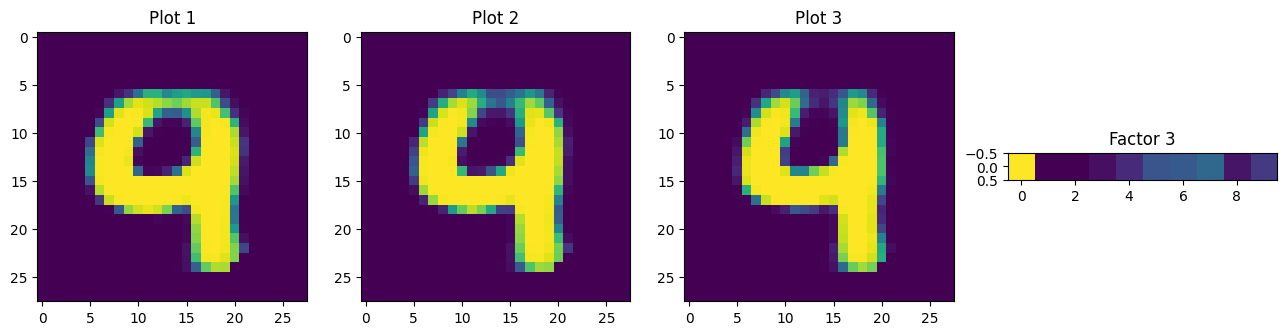

In [6]:
h1_to_out_13 = LinearCorex(n_hidden=30, seed=42, gaussianize='outliers')
x = np.concatenate([model_data[1][indexes[partition]], model_data[0][indexes[partition]]], axis=1)
Y1_0 = h1_to_out_13.fit_transform(x)

print(h1_to_out_13.tcs)

multi_rep_plot(h1_to_out_13, 3, dims=[(20,25),(10,1)], num_per_row=2)
hidden_state_plot(x, h1_to_out_13, do_ae, scaler=1, latent_dim=500, encoder_layer=1)

In [7]:
do_clf.to('cpu')
pred_digit = do_clf(torch.tensor(inputs)).max(1).indices.detach().numpy()
base_accuracies = []
for i in range(num_clusters):
    base_accuracies.append(100*np.mean(pred_digit[indexes[i]] == labels[indexes[i]]))
    print(i, np.round(np.mean(pred_digit[indexes[i]] == labels[indexes[i]]) * 100, 2))

0 98.61
1 99.63
2 96.71
3 99.63
4 98.03
5 99.05
6 98.71
7 99.54
8 99.07
9 98.96
10 98.74
11 98.58
12 97.83
13 99.0
14 99.75
15 99.02
16 99.0
17 97.03
18 98.43
19 98.06


In [8]:
from nn_utils import compute_cluster_accuracies

base_accuracies, base_probs = compute_cluster_accuracies(
    do_clf, data_module.predict_dataloader(), 'cpu', indexes, return_probs=True
)

  0%|          | 0/313 [00:00<?, ?it/s]

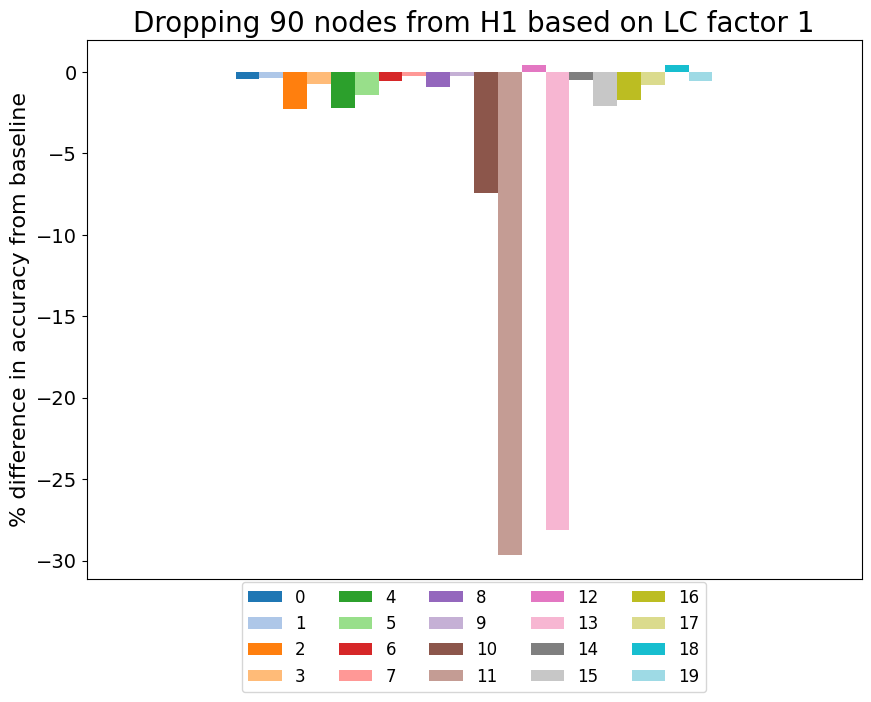

In [9]:
diff_probs = plot_perturved_accuracy(do_clf, h1_to_out_13, inputs, labels, indexes, base_probs=base_probs,
                             factor_num=0, hidden_layer_idx=0, num_clusters=20, 
                             num_drop=90, hidden_dim=500)

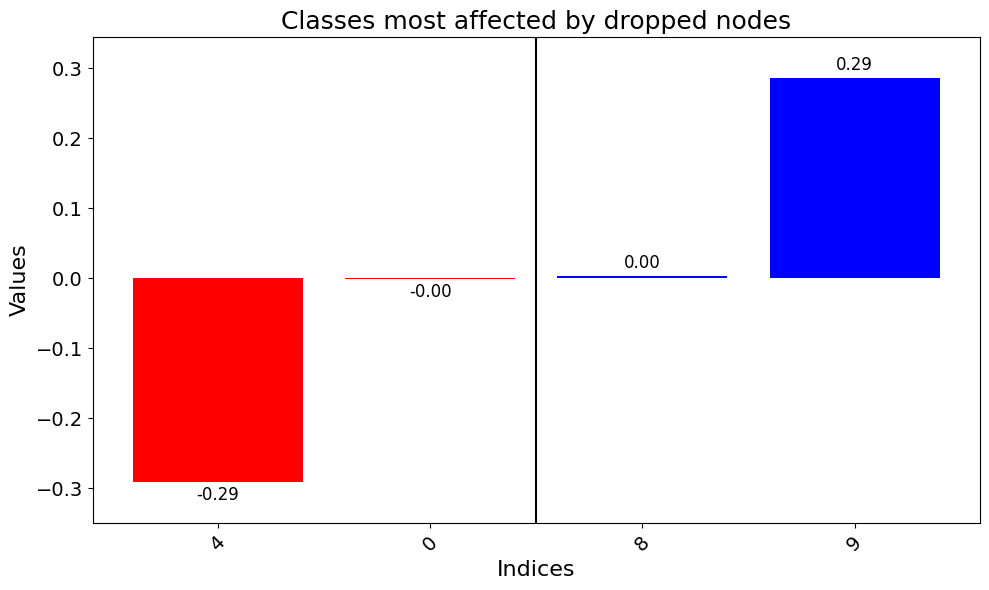

In [10]:

class_names = [str(i) for i in range(10)]
plot_logit_effects(
    torch.mean(diff_probs[indexes[partition]], dim=0), 
    class_names, 
    bottom_vals=2,
    top_vals=2
)

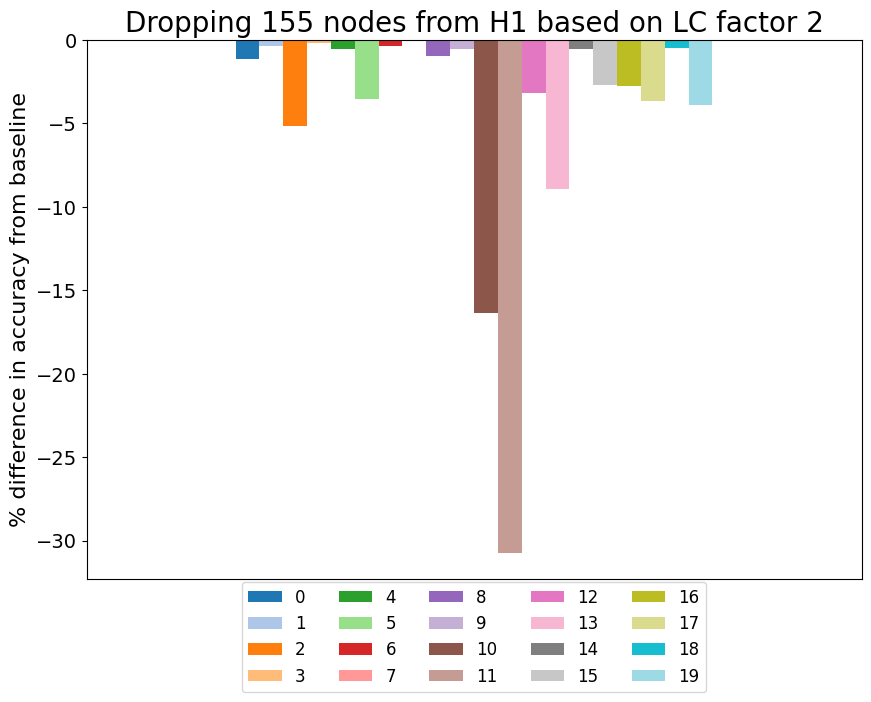

In [11]:
diff_probs = plot_perturved_accuracy(do_clf, h1_to_out_13, inputs, labels, indexes, base_probs=base_probs,
                             factor_num=1, hidden_layer_idx=0, num_clusters=20, 
                             num_drop=155, hidden_dim=500)

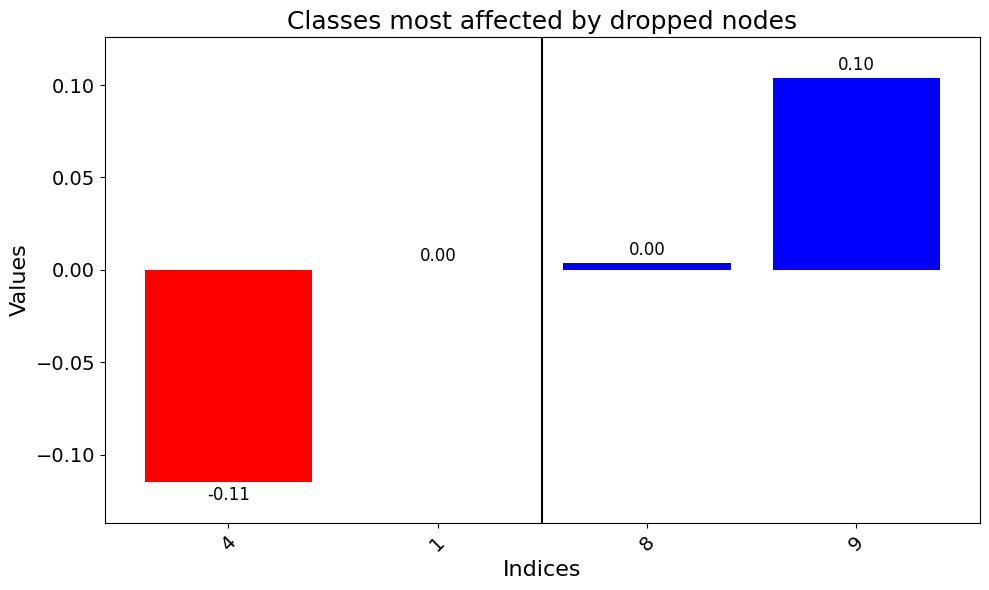

In [12]:

class_names = [str(i) for i in range(10)]
plot_logit_effects(
    torch.mean(diff_probs[indexes[partition]], dim=0), 
    class_names, 
    bottom_vals=2,
    top_vals=2
)

138.0


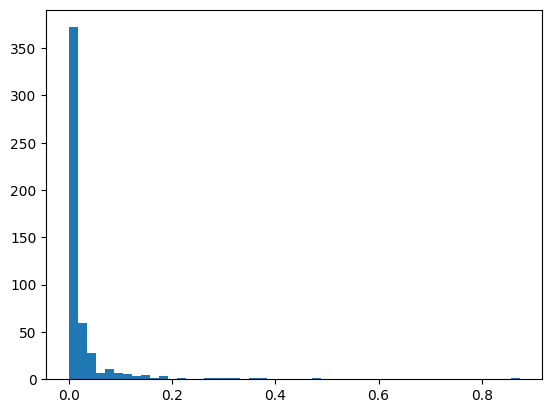

In [13]:
output = plt.hist(h1_to_out_13.moments['MI'][2], bins=50)
print(np.sum(output[0][1:]))

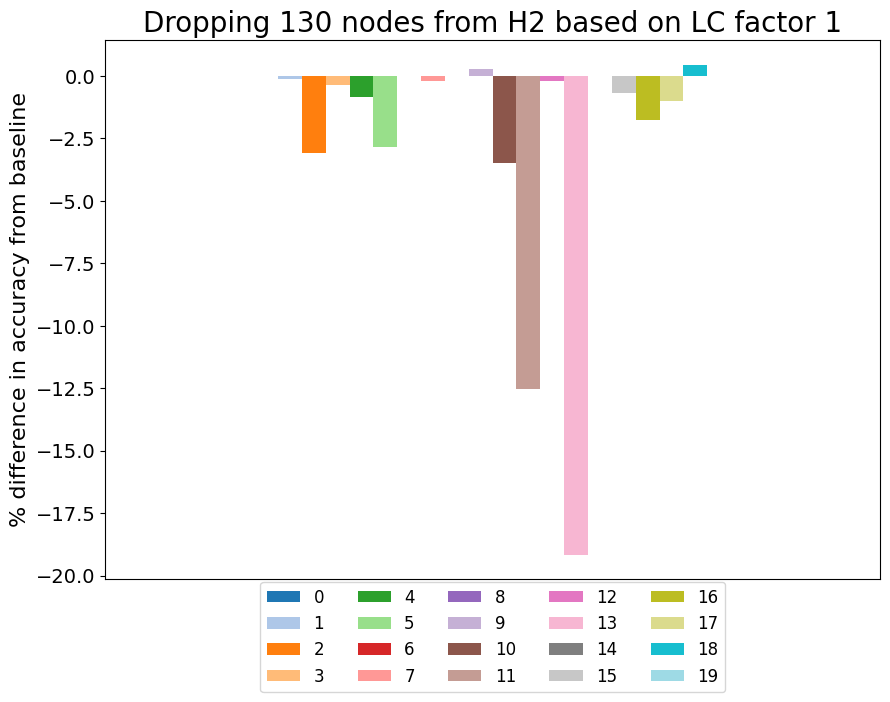

In [15]:
diff_probs = plot_perturved_accuracy(do_clf, h2_to_out_13, inputs, labels, indexes, base_probs=base_probs,
                             factor_num=0, hidden_layer_idx=1, num_clusters=20, 
                             num_drop=130, hidden_dim=400)

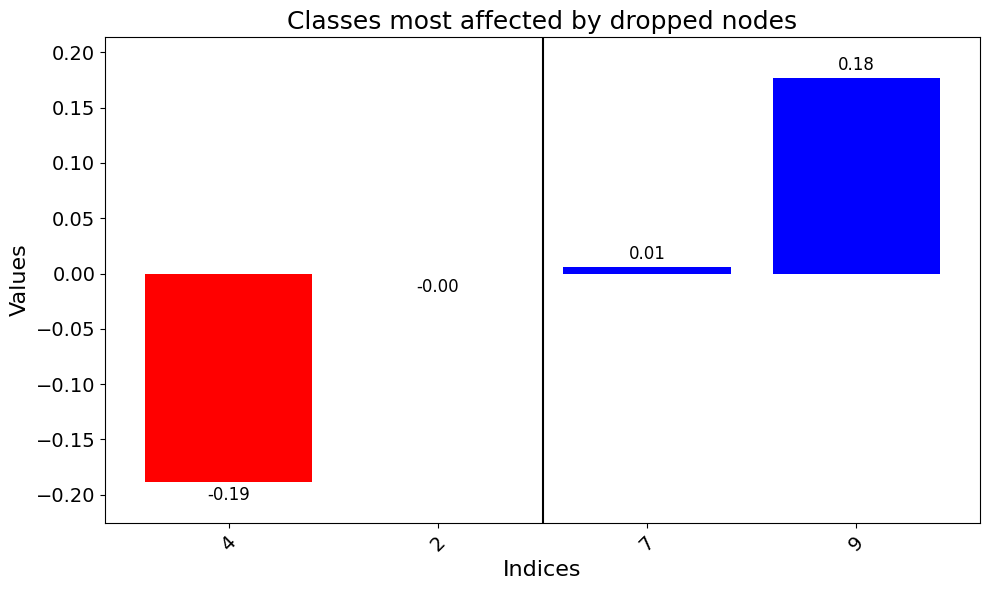

In [16]:

class_names = [str(i) for i in range(10)]
plot_logit_effects(
    torch.mean(diff_probs[indexes[partition]], dim=0), 
    class_names, 
    bottom_vals=2,
    top_vals=2
)

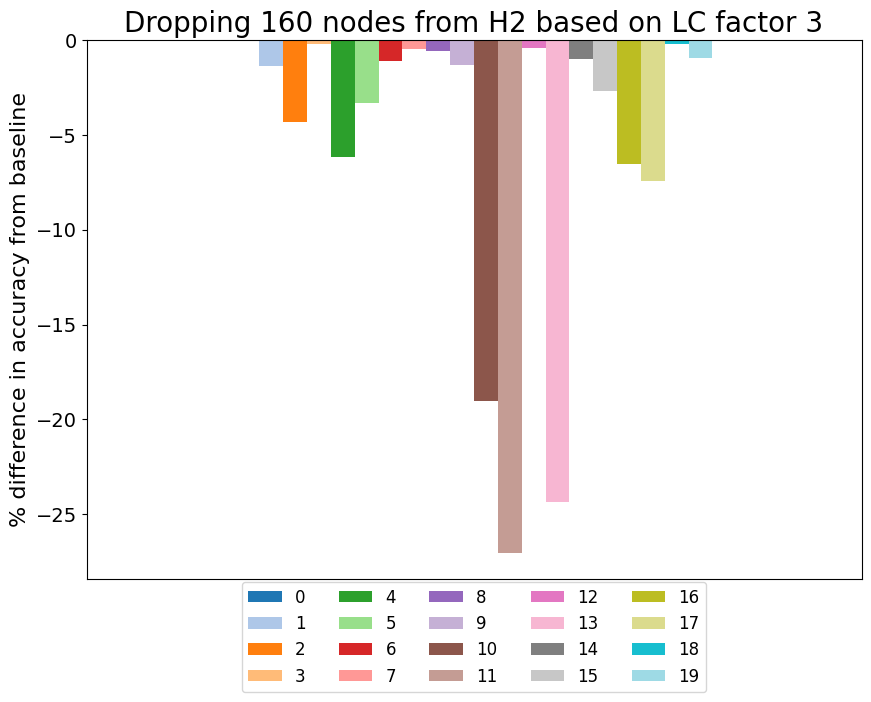

In [17]:
diff_probs = plot_perturved_accuracy(do_clf, h2_to_out_13, inputs, labels, indexes, base_probs=base_probs,
                             factor_num=2, hidden_layer_idx=1, num_clusters=20, 
                             num_drop=160, hidden_dim=400)

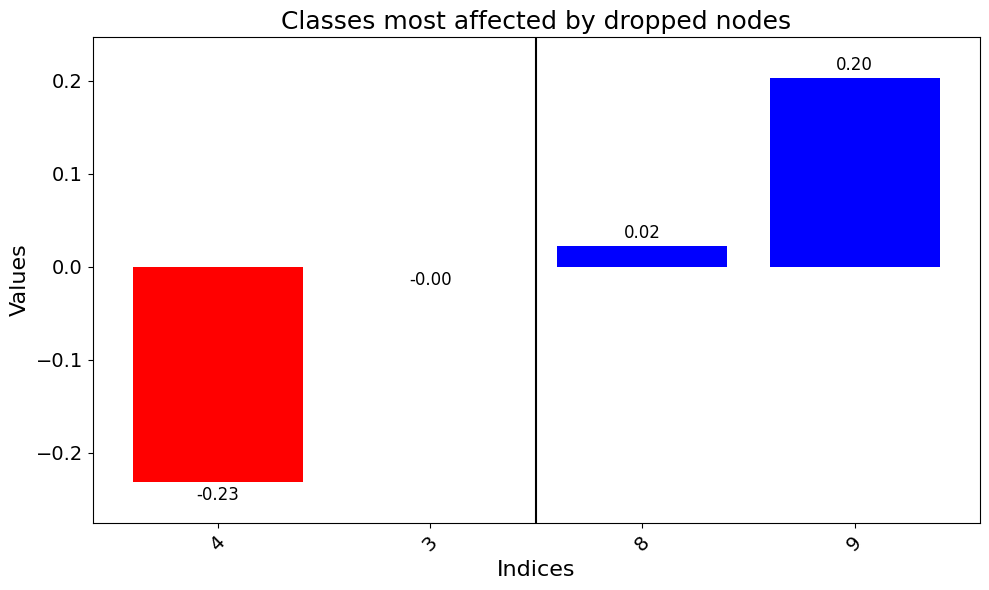

In [18]:

class_names = [str(i) for i in range(10)]
plot_logit_effects(
    torch.mean(diff_probs[indexes[partition]], dim=0), 
    class_names, 
    bottom_vals=2,
    top_vals=2
)

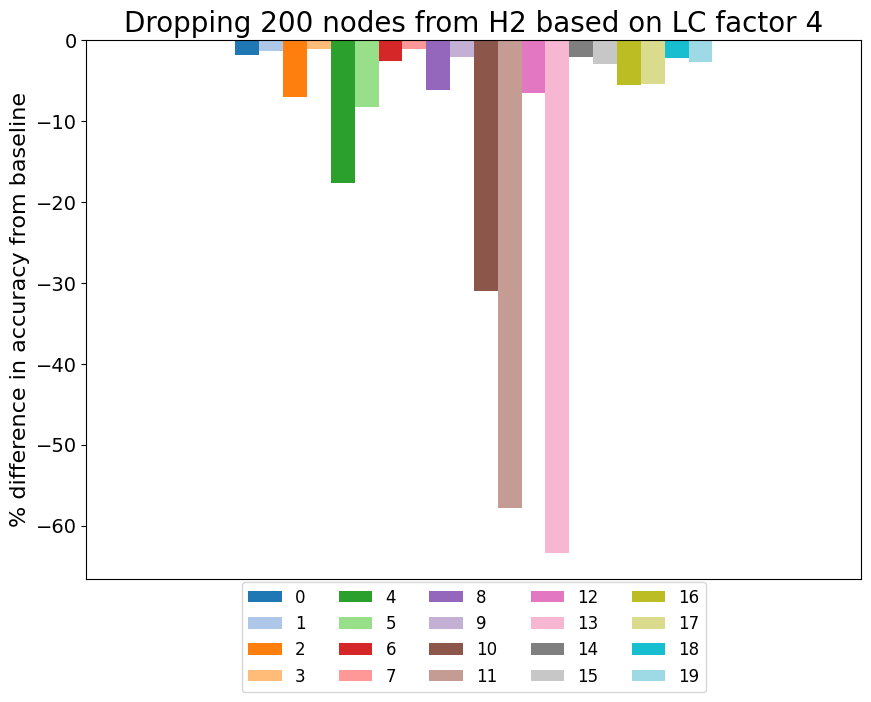

In [19]:
diff_probs = plot_perturved_accuracy(do_clf, h2_to_out_13, inputs, labels, indexes, base_probs=base_probs,
                             factor_num=3, hidden_layer_idx=1, num_clusters=20, 
                             num_drop=200, hidden_dim=400)

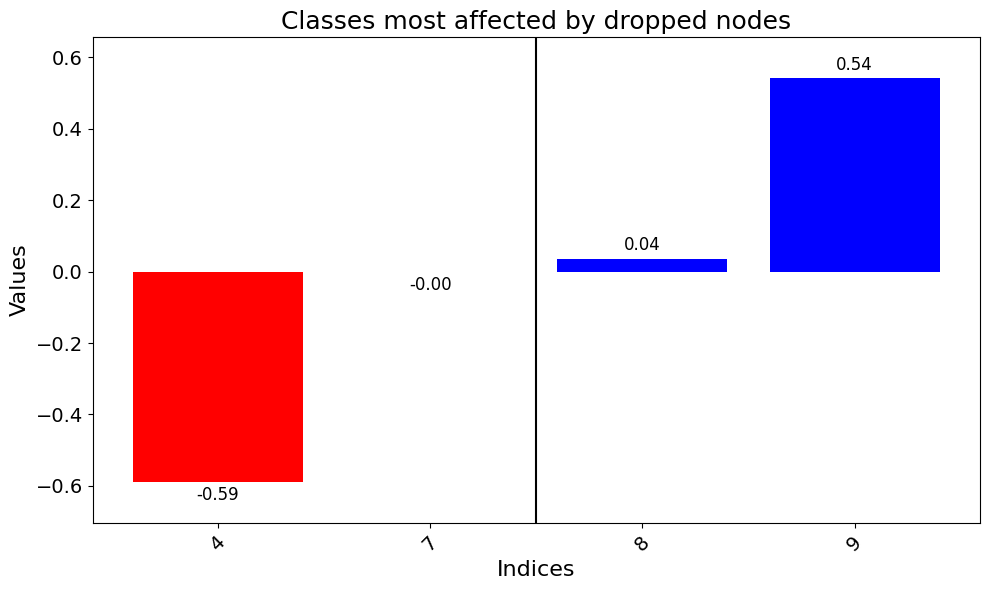

In [20]:

class_names = [str(i) for i in range(10)]
plot_logit_effects(
    torch.mean(diff_probs[indexes[partition]], dim=0), 
    class_names, 
    bottom_vals=2,
    top_vals=2
)

92.0


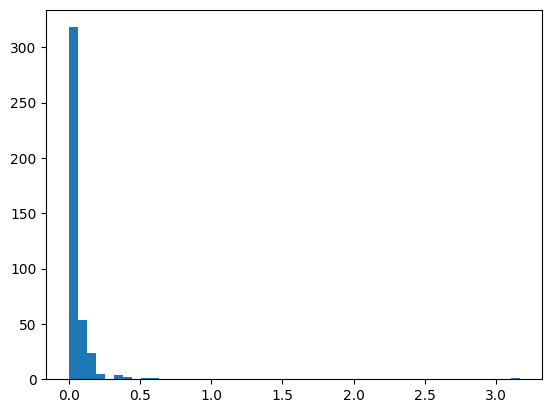

In [21]:
output = plt.hist(h2_to_out_13.moments['MI'][0], bins=50)
print(np.sum(output[0][1:]))

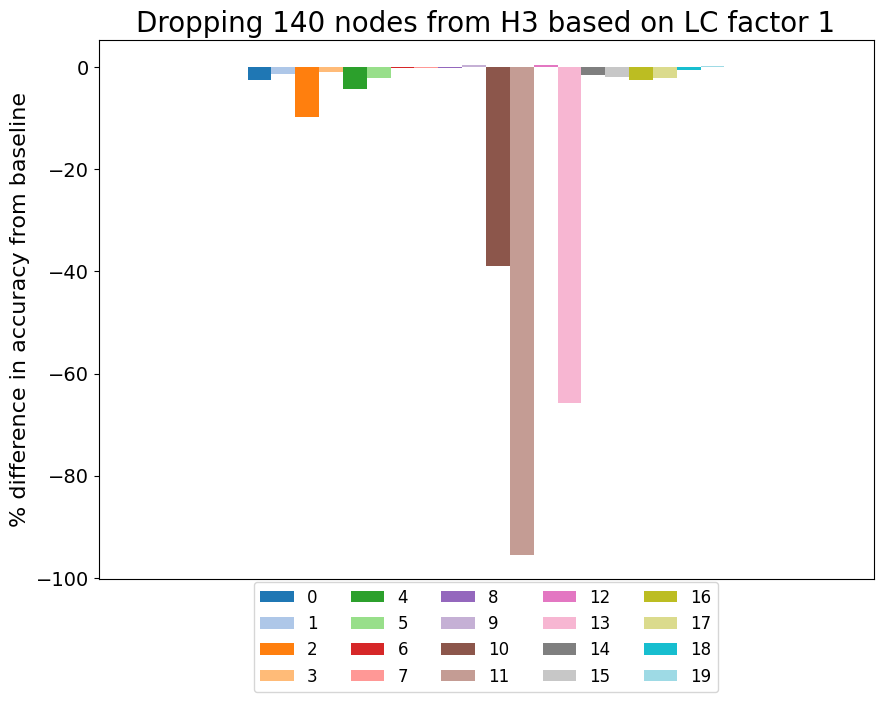

In [22]:
diff_probs = plot_perturved_accuracy(do_clf, h3_to_out_13, inputs, labels, indexes, base_probs=base_probs,
                             factor_num=0, hidden_layer_idx=2, num_clusters=20, 
                             num_drop=140, hidden_dim=300)

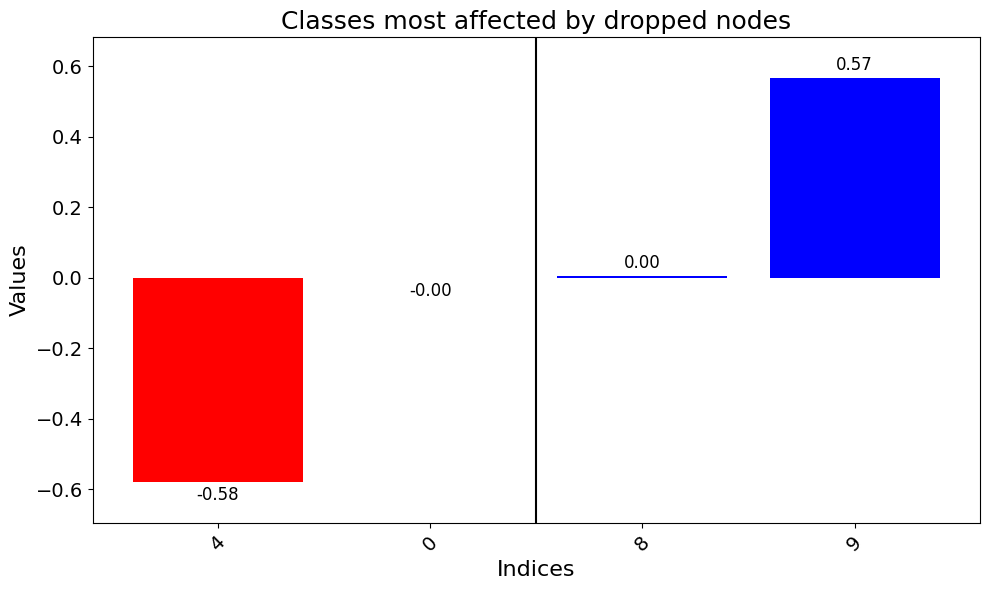

In [23]:

class_names = [str(i) for i in range(10)]
plot_logit_effects(
    torch.mean(diff_probs[indexes[partition]], dim=0), 
    class_names, 
    bottom_vals=2,
    top_vals=2
)

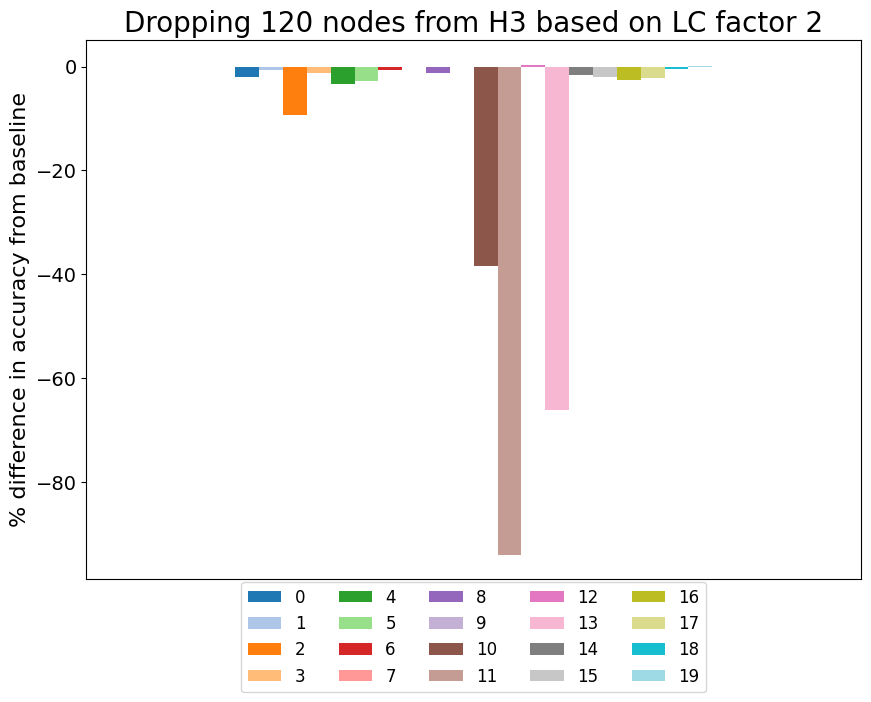

In [24]:
diff_probs = plot_perturved_accuracy(do_clf, h3_to_out_13, inputs, labels, indexes, base_probs=base_probs,
                             factor_num=1, hidden_layer_idx=2, num_clusters=20, 
                             num_drop=120, hidden_dim=300)

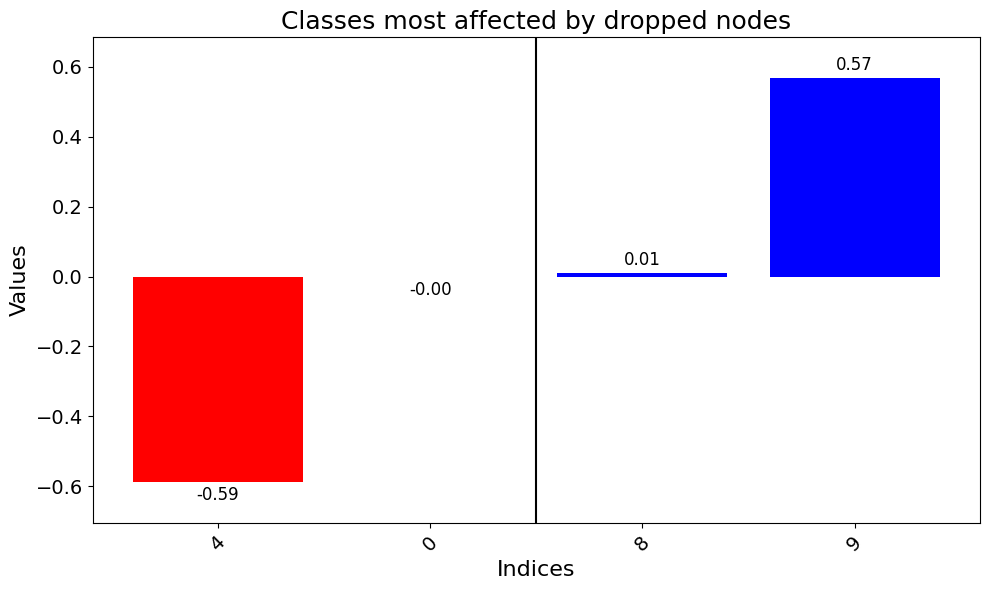

In [25]:

class_names = [str(i) for i in range(10)]
plot_logit_effects(
    torch.mean(diff_probs[indexes[partition]], dim=0), 
    class_names, 
    bottom_vals=2,
    top_vals=2
)

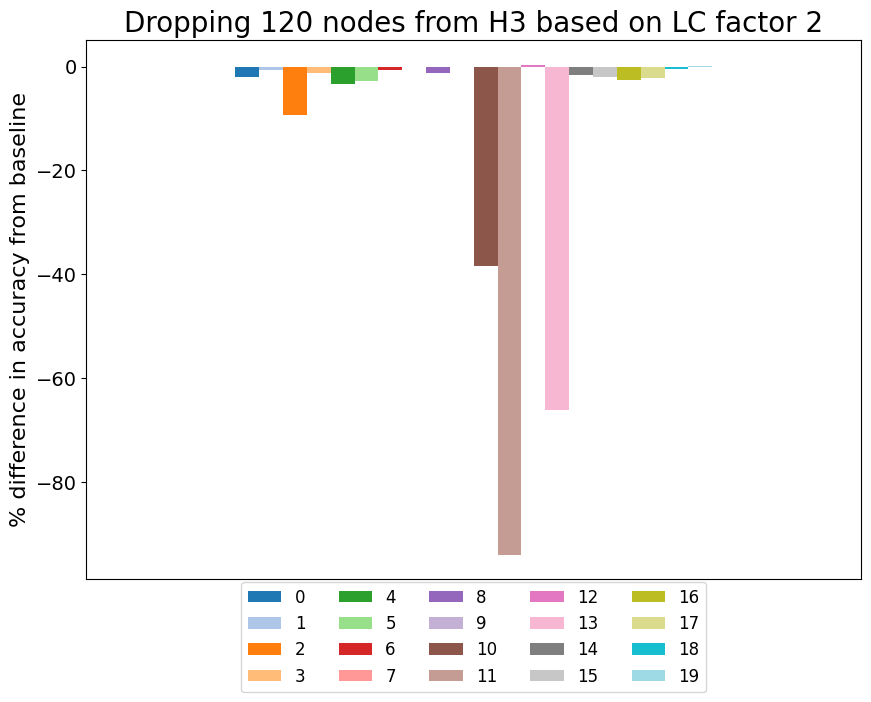

In [26]:
diff_probs = plot_perturved_accuracy(do_clf, h3_to_out_13, inputs, labels, indexes, base_probs=base_probs,
                             factor_num=1, hidden_layer_idx=2, num_clusters=20, 
                             num_drop=120, hidden_dim=300)

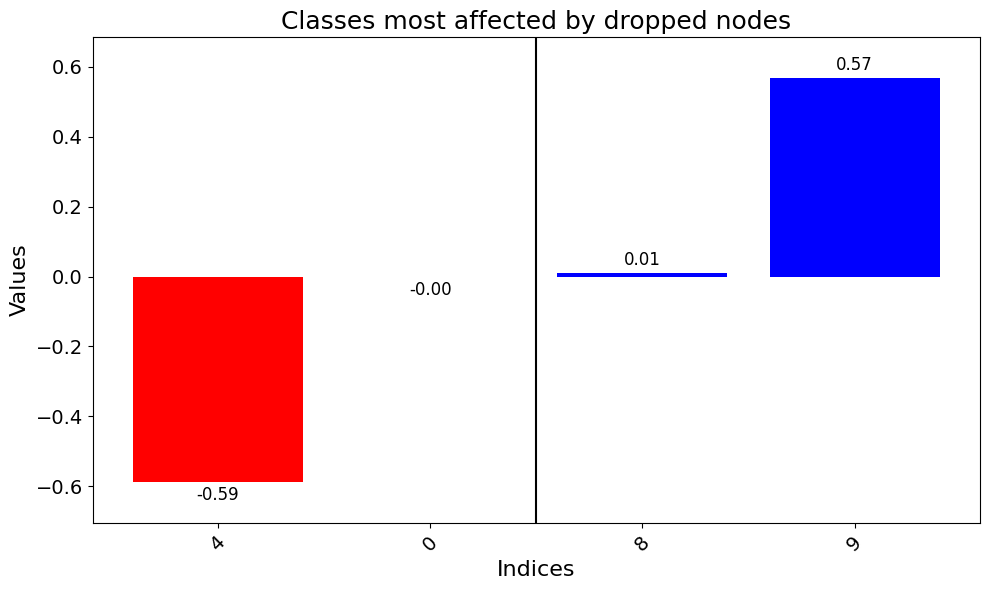

In [27]:

class_names = [str(i) for i in range(10)]
plot_logit_effects(
    torch.mean(diff_probs[indexes[partition]], dim=0), 
    class_names, 
    bottom_vals=2,
    top_vals=2
)

Cluster number: 0


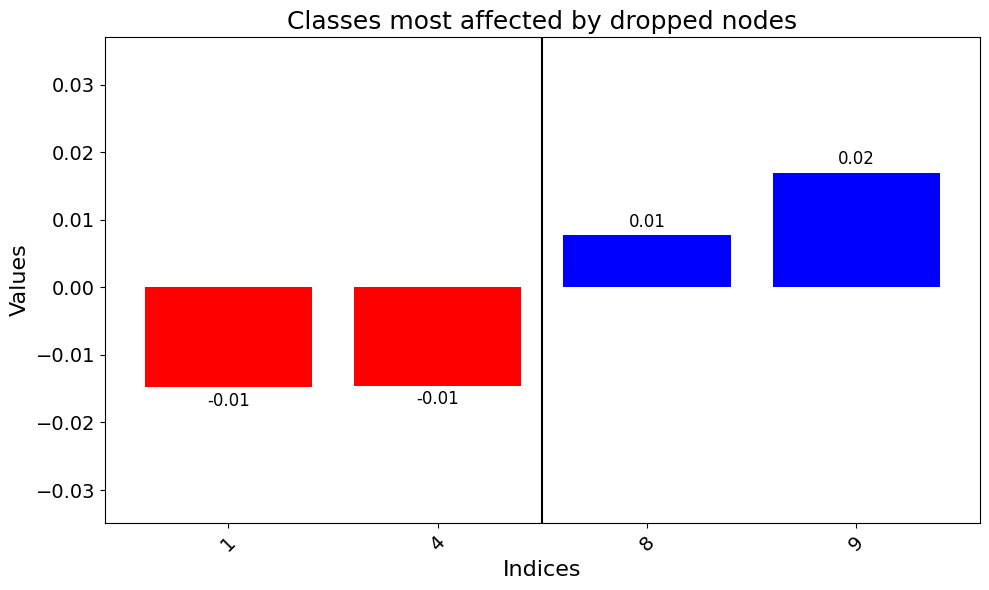

Cluster number: 1


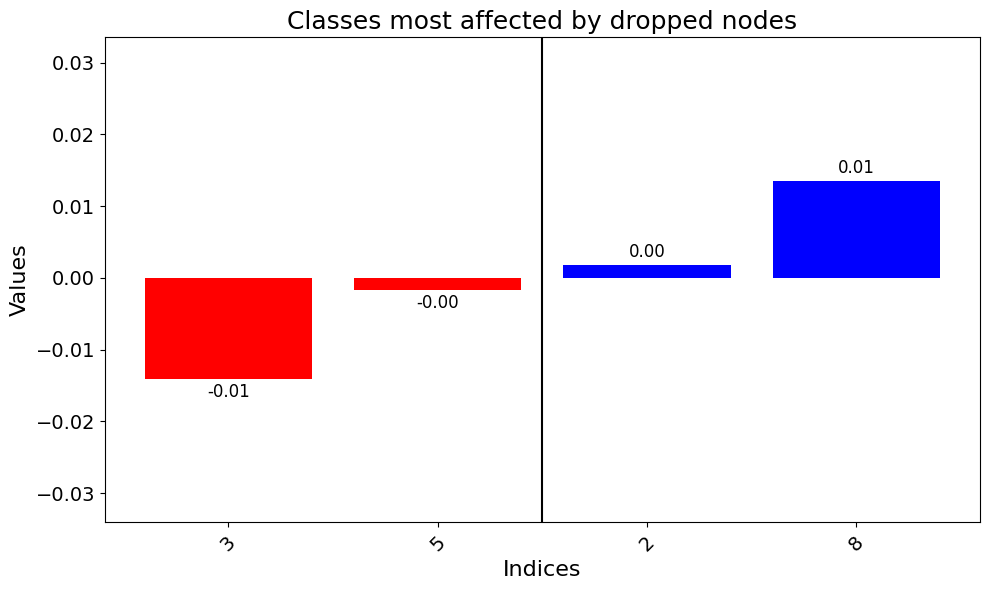

Cluster number: 2


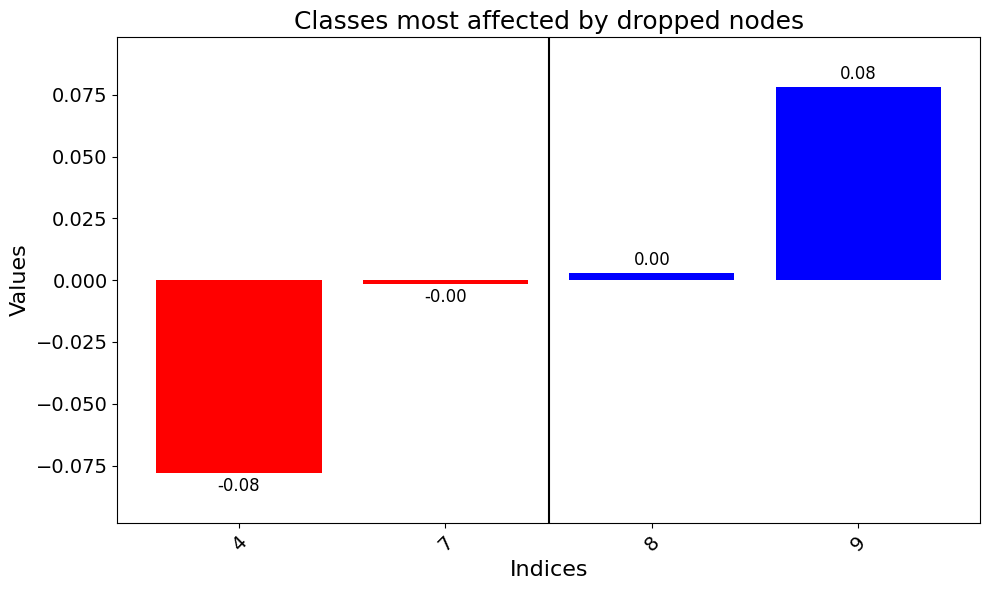

Cluster number: 3


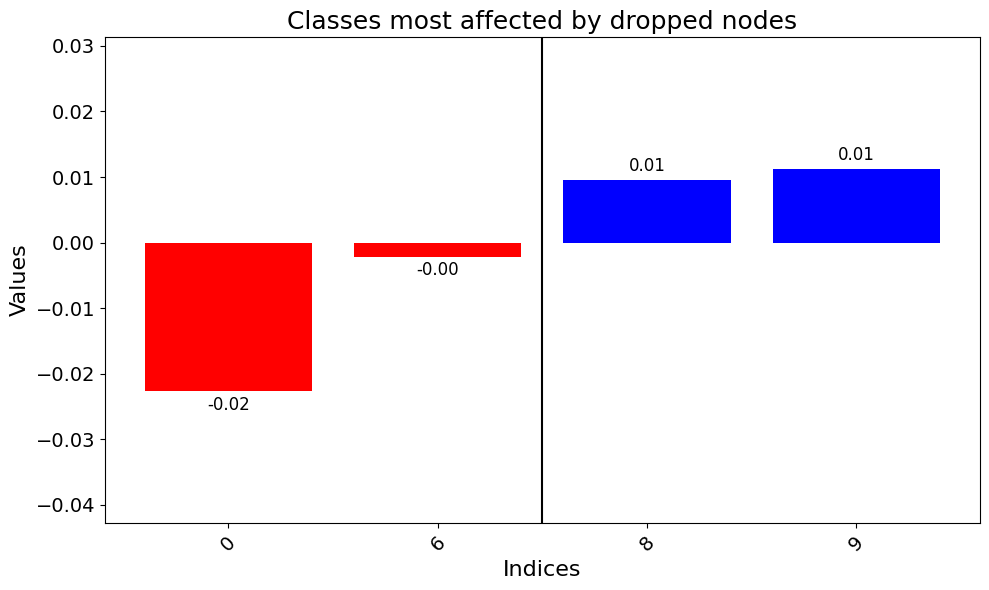

Cluster number: 4


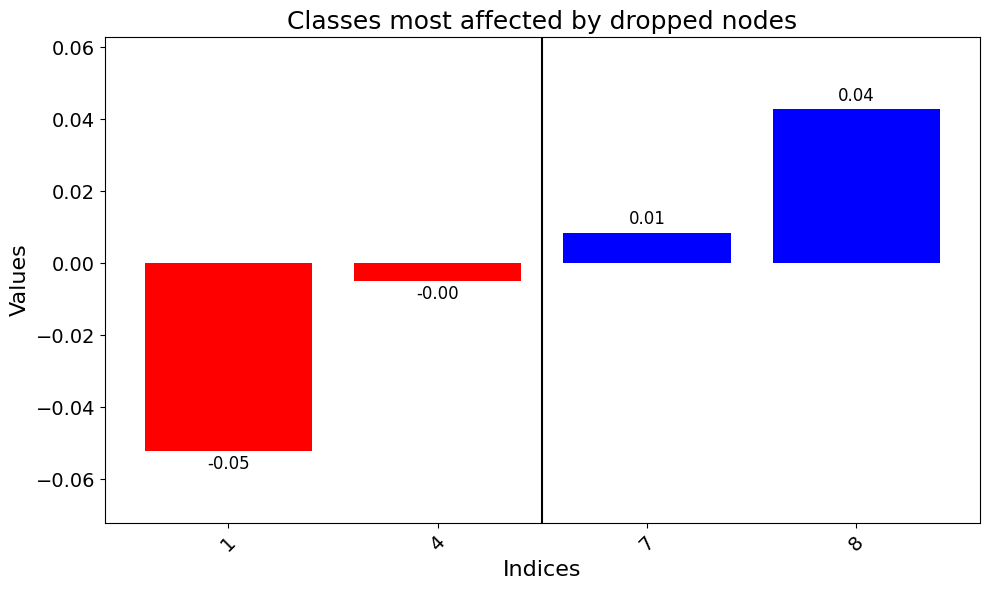

Cluster number: 5


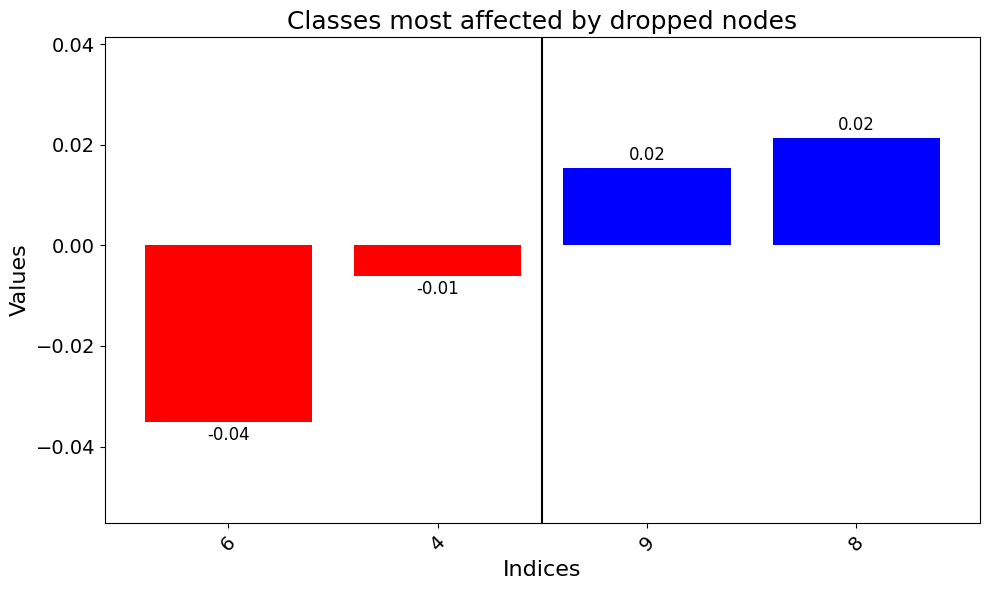

Cluster number: 6


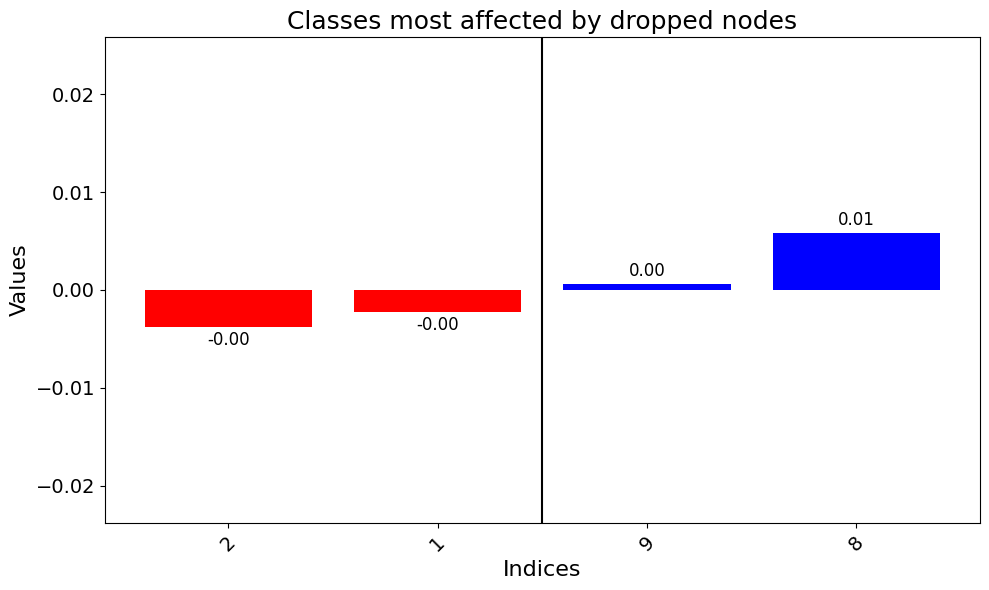

Cluster number: 7


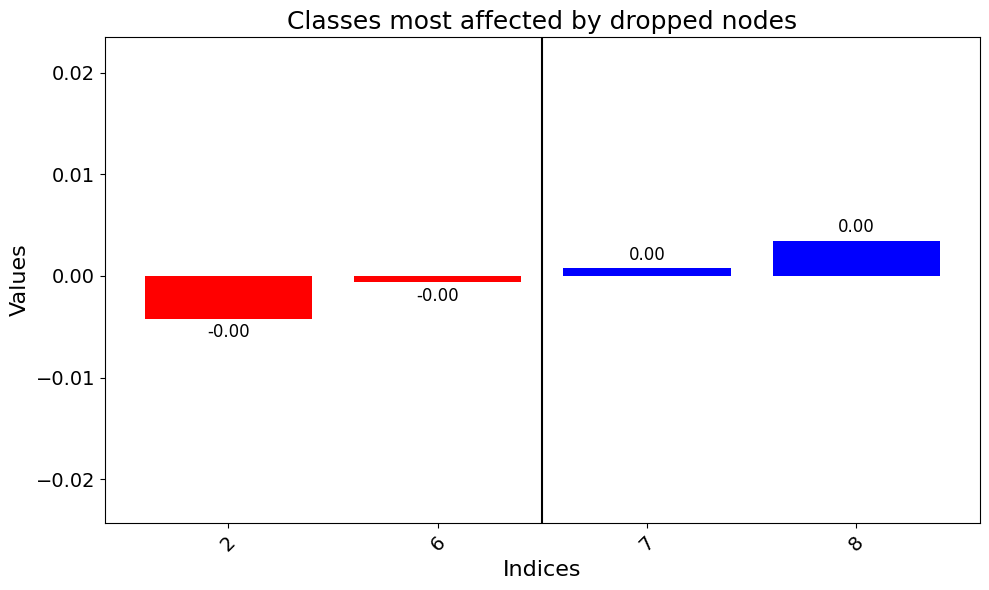

Cluster number: 8


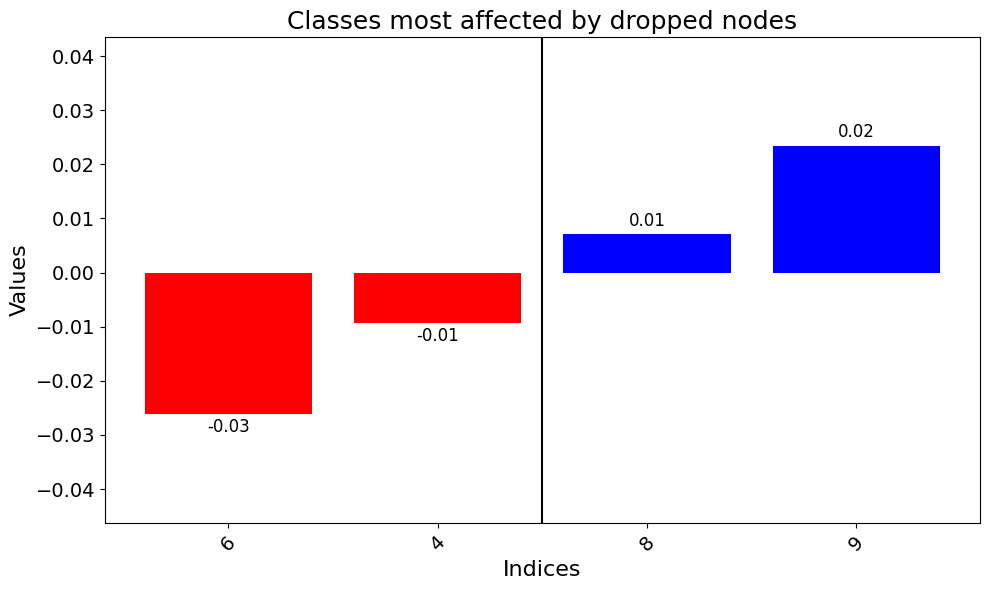

Cluster number: 9


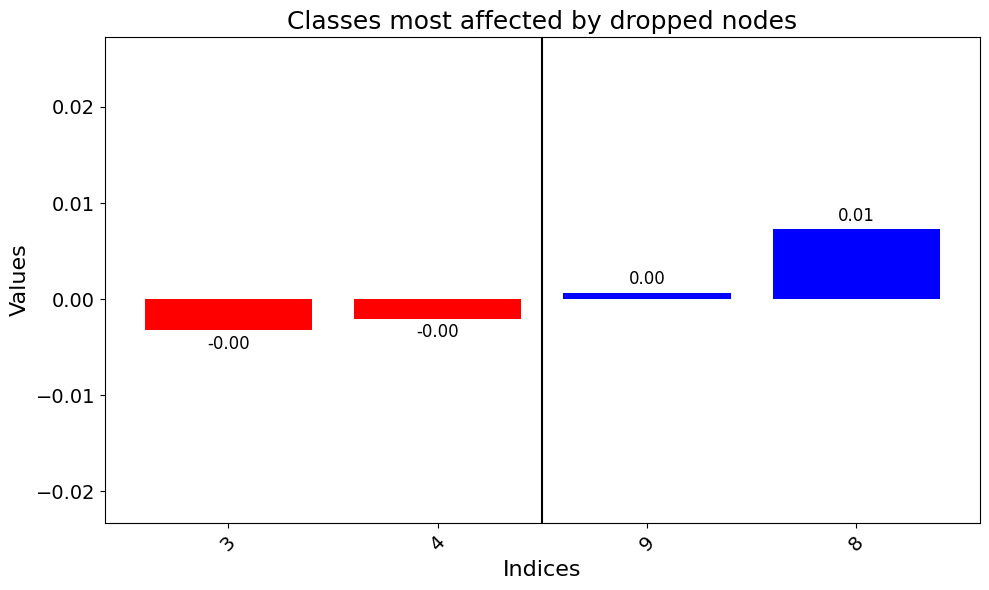

Cluster number: 10


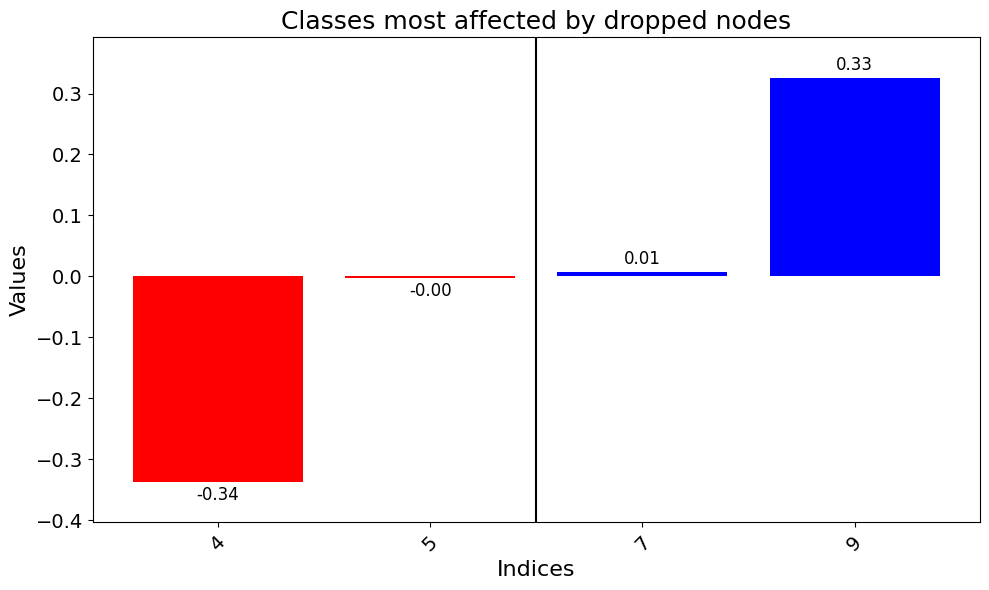

Cluster number: 11


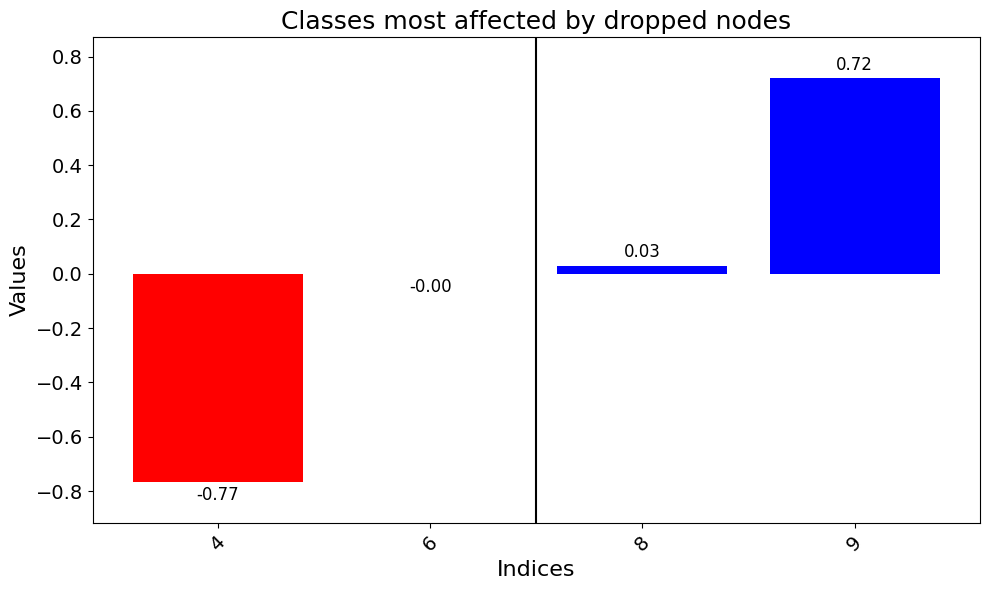

Cluster number: 12


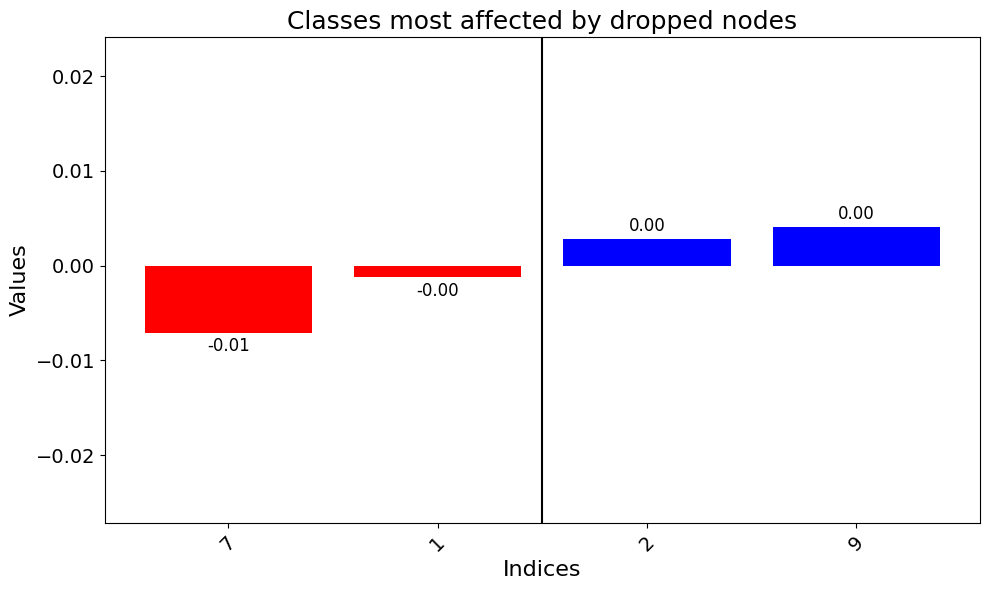

Cluster number: 13


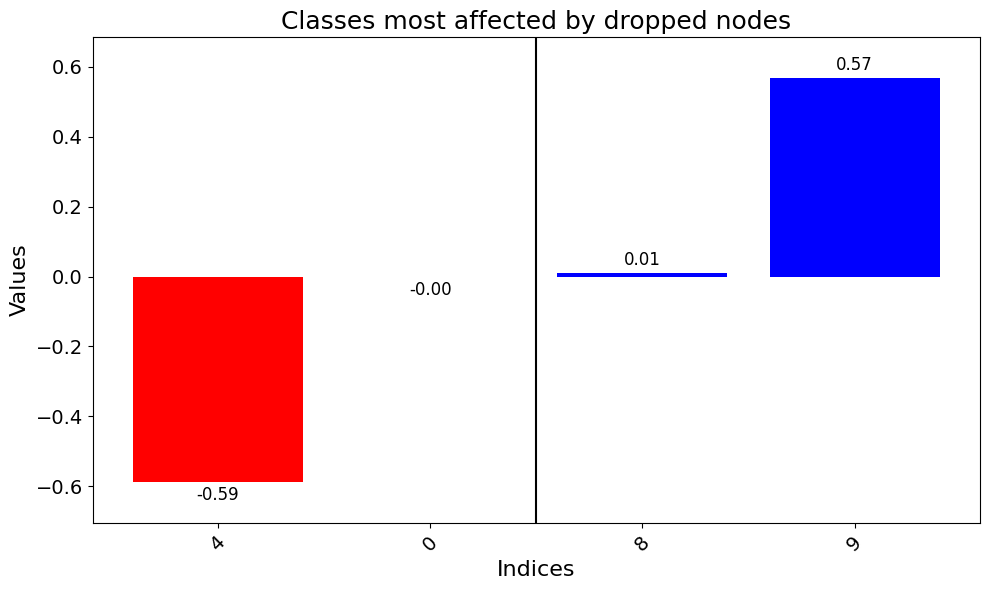

Cluster number: 14


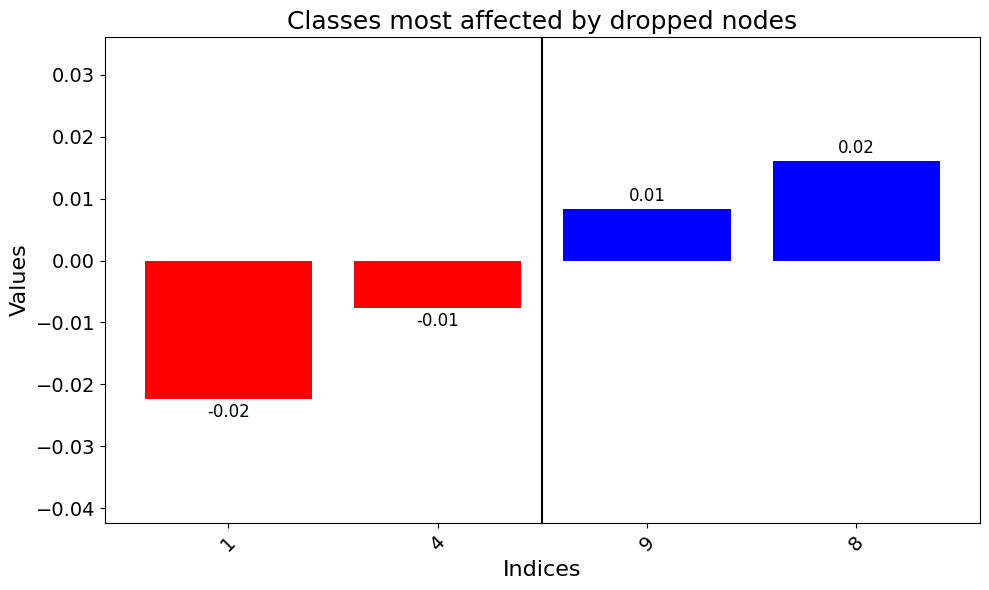

Cluster number: 15


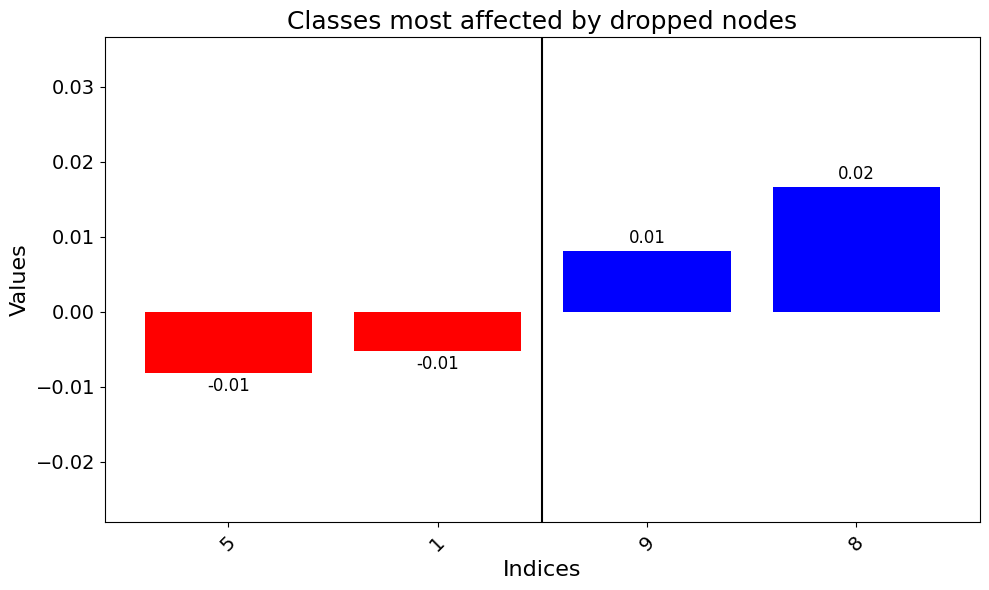

Cluster number: 16


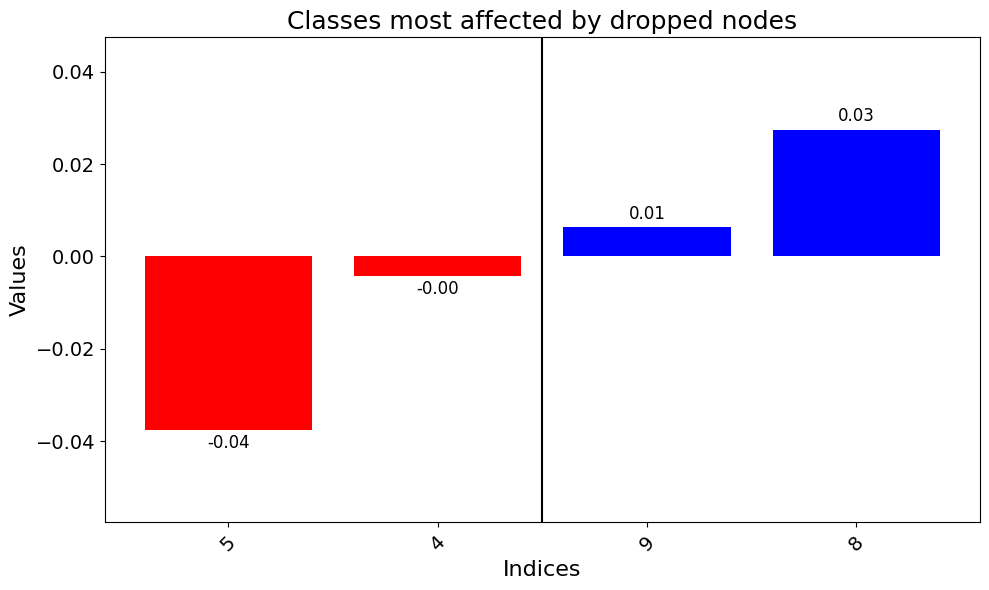

Cluster number: 17


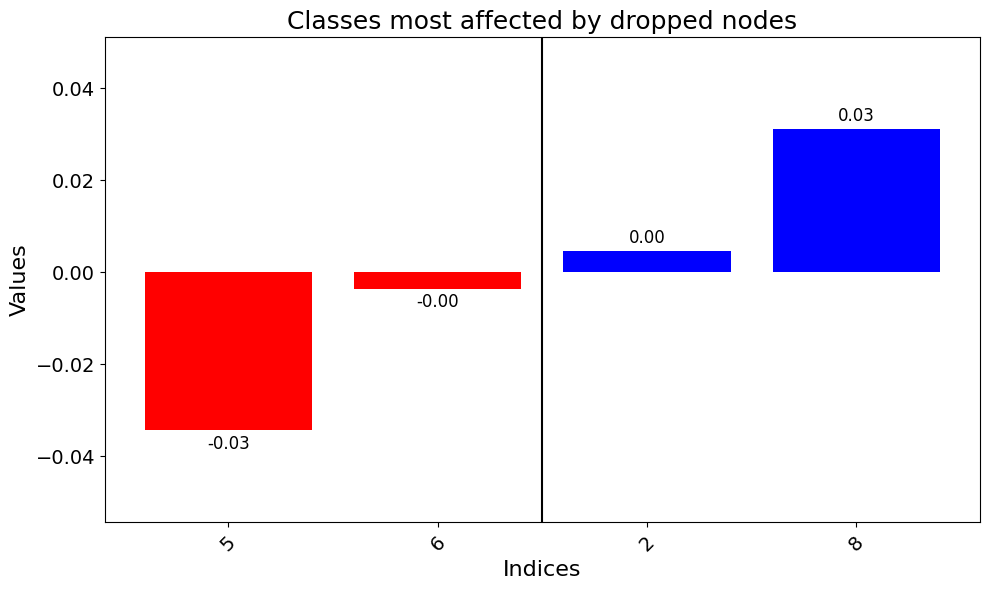

Cluster number: 18


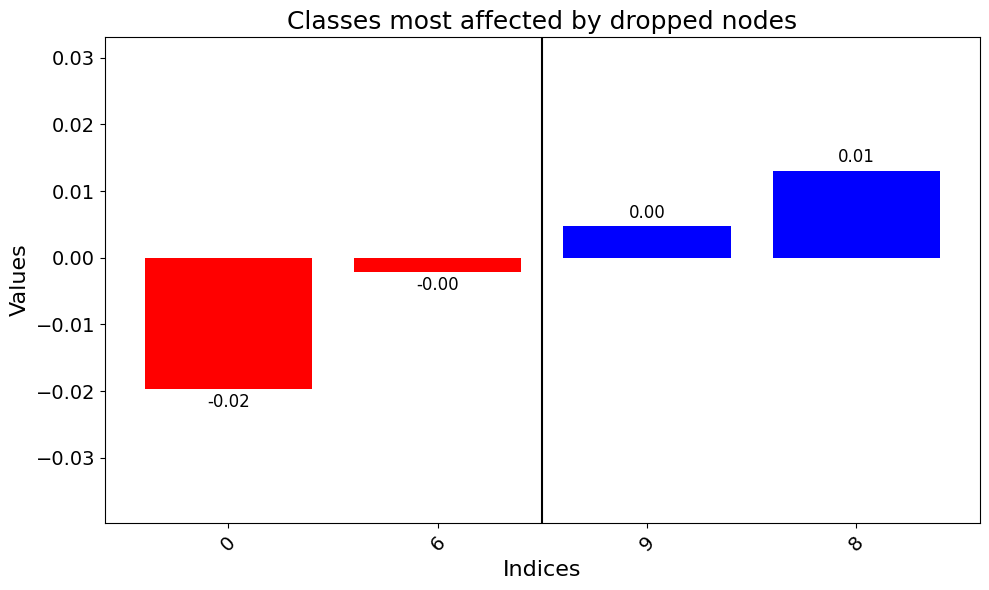

Cluster number: 19


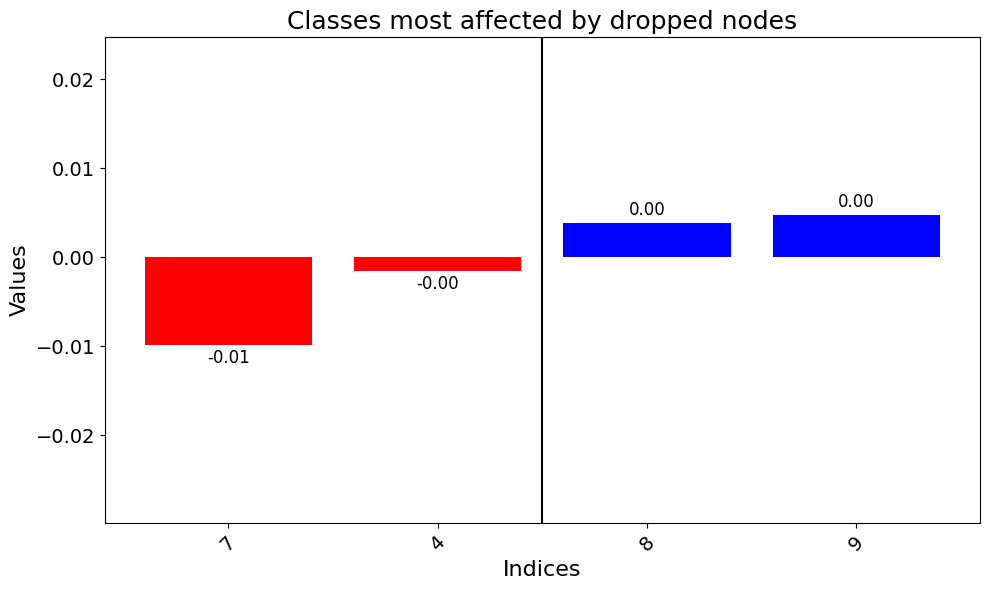

In [30]:
class_names = [str(i) for i in range(10)]
for i in range(20):
    print("Cluster number:", i)
    plot_logit_effects(
        torch.mean(diff_probs[indexes[i]], dim=0), 
        class_names, 
        bottom_vals=2,
        top_vals=2
    )
    plt.show()

In [ ]:
output = plt.hist(h3_to_out_13.moments['MI'][5], bins=50)
print(np.sum(output[0][3:]))